**Pengecekan Dataset lewat Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

DATASET_PATH = Path(
    "/content/drive/MyDrive/Dataset ML/Dataset Slingbag & Totebag"
)

print("Dataset ditemukan:", DATASET_PATH.exists())
print(DATASET_PATH)

Dataset ditemukan: True
/content/drive/MyDrive/Dataset ML/Dataset Slingbag & Totebag


In [ ]:
import os

print(os.listdir(DATASET_PATH))

['Slingbag', 'Totebag']


In [ ]:
classes = ["Slingbag", "Totebag"]

for class_name in classes:
    folder = DATASET_PATH / class_name

    image_count = len(list(folder.glob("*.jpg")))

    print(f"{class_name}: {image_count} gambar")

Slingbag: 500 gambar
Totebag: 500 gambar


In [ ]:
total_images = 0

for class_name in classes:
    folder = DATASET_PATH / class_name
    total_images += len(list(folder.glob("*.jpg")))

print(f"Total gambar: {total_images}")

Total gambar: 1000


In [ ]:
from PIL import Image

corrupted_files = []

for class_name in classes:
    folder = DATASET_PATH / class_name

    for image_path in folder.glob("*.jpg"):
        try:
            img = Image.open(image_path)
            img.verify()
        except:
            corrupted_files.append(str(image_path))

print(f"Jumlah gambar corrupt: {len(corrupted_files)}")

if len(corrupted_files) > 0:
    print("\nDaftar file corrupt:")
    for file in corrupted_files:
        print(file)

Jumlah gambar corrupt: 0


In [ ]:
from PIL import Image
import pandas as pd

image_sizes = []

for class_name in classes:
    folder = DATASET_PATH / class_name

    for image_path in folder.glob("*.jpg"):
        img = Image.open(image_path)

        width, height = img.size

        image_sizes.append({
            "class": class_name,
            "width": width,
            "height": height
        })

df_sizes = pd.DataFrame(image_sizes)

df_sizes.head()

,class,width,height
0,Slingbag,3000,4000
1,Slingbag,3000,4000
2,Slingbag,3000,4000
3,Slingbag,3000,4000
4,Slingbag,3000,4000


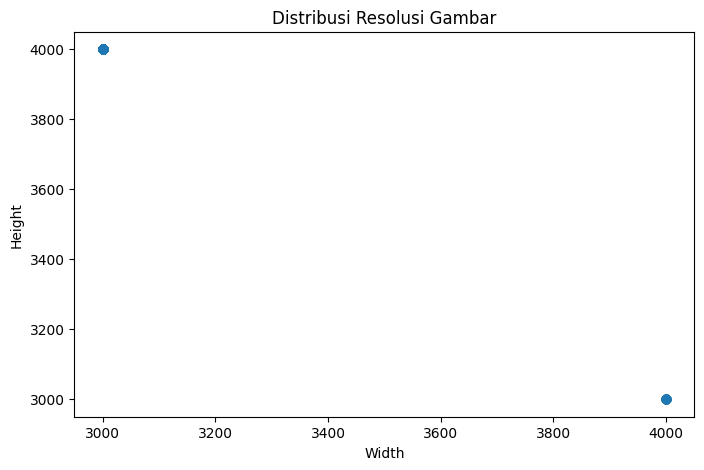

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df_sizes["width"],
    df_sizes["height"],
    alpha=0.5
)

plt.xlabel("Width")
plt.ylabel("Height")
plt.title("Distribusi Resolusi Gambar")
plt.show()

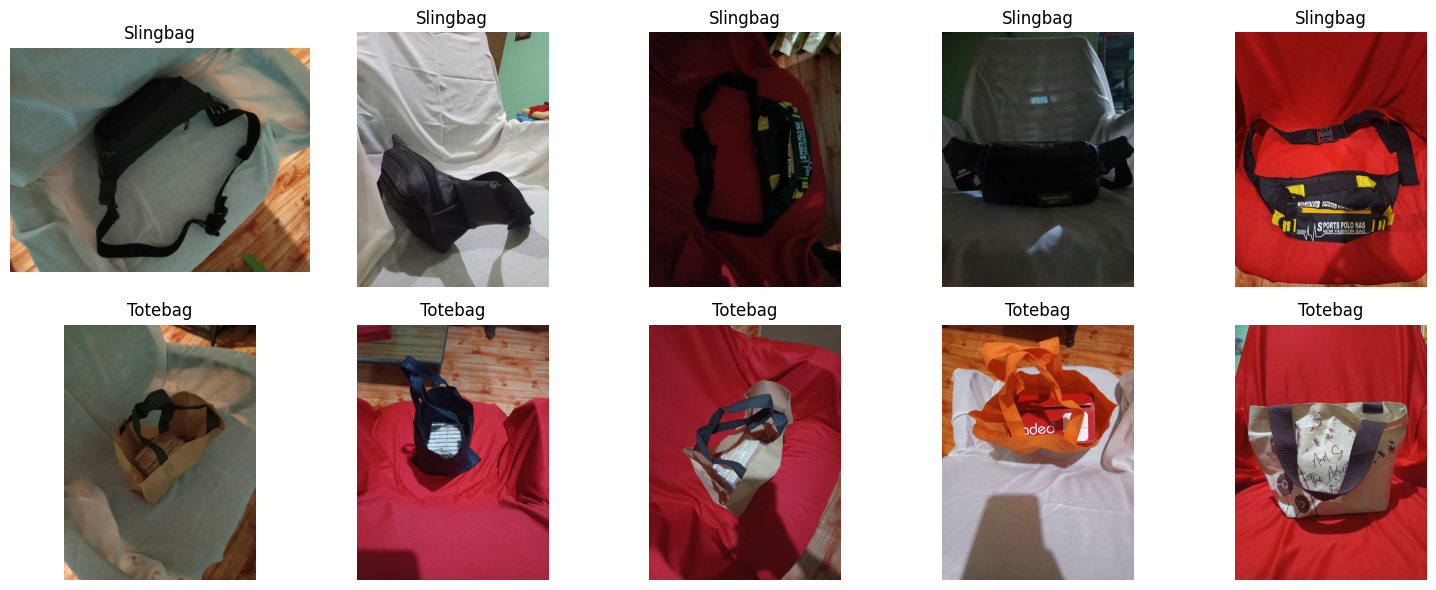

In [ ]:
import matplotlib.pyplot as plt
import random
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for row, class_name in enumerate(classes):

    folder = DATASET_PATH / class_name

    sample_images = random.sample(
        list(folder.glob("*.jpg")),
        5
    )

    for col, image_path in enumerate(sample_images):

        img = Image.open(image_path)

        axes[row, col].imshow(img)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()